# 1) Introdução ao Kaggle

**Status:** Feito

# 2) Git e GitHub

**Status:** fazer no final

# 3) Python

##3.1 Exercıcio — Análise de Sentimentos no Twitter

In [1]:
#1
tweets = [
"Wow, what a great day today!! #sunshine",
"I feel sad about the things going on around us. #covid19",
"I'm really excited to learn Python with @JovianML #zerotopandas",
"This is a really nice song. #linkinpark",
"The Python programming language is useful for data science",
"Why do bad things happen to me?",
"Apple announces the release of the new iPhone 12. Fans are excited.",
"Spent my day with family!! #happy",
"Check out my blog post on common string operations in Python. #zerotopandas",
"Freecodecamp has great coding tutorials. #skillup"
]
#1
numero_tweets=len(tweets)
print(numero_tweets)


10


In [2]:
#2
happy_words = ['great', 'excited', 'happy', 'nice', 'wonderful',
               'amazing', 'good', 'best']
sad_words = ['sad', 'bad', 'tragic', 'unhappy', 'worst']
p_tweet= tweets[0]

is_happy=False
for palavra in happy_words:
  if palavra in p_tweet:
    is_happy=True

is_sad = False
for palavra in sad_words:
    if palavra in p_tweet:
        is_sad = True
if is_happy==True:
  print(f"'{p_tweet}' é feliz")
else:
  print(f"'{p_tweet}' não é feliz")

'Wow, what a great day today!! #sunshine' é feliz


In [3]:
#3
contador_feliz=0
contador_triste=0
for tweer in tweets:
  for palavra in happy_words:
    if palavra in tweer:
      contador_feliz+=1
  for palavra in sad_words:
    if palavra in tweer:
      contador_triste+=1
print(f'tweets felizes: {contador_feliz}')
print(f'tweets tristes: {contador_triste}')
#

tweets felizes: 6
tweets tristes: 2


In [4]:
#único problema é que vai conta duas vezes se tiver duas palavras felizes

# 4) Pandas

## 4.1) Análise exploratória inicial do dataset COVID-19

In [5]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/Data/covid_19_clean_complete.csv')
df.info()



Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [6]:
#colunas
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [7]:
#trasnformando em datetime
df['Date']=pd.to_datetime(df['Date'])
df.head(15)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [8]:
#Estatisticas e nulos
df.describe()
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


## 4.2) Análise por províncias da China

In [9]:
#China,
df_china=df.query('`Country/Region`=="China"')
#china=df['Country/Region']=='China'
#print(china)
#df_china=df[china]


In [10]:
df_china.head(15)



,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific
53,Guangdong,China,23.3417,113.4244,2020-01-22,26,0,0,26,Western Pacific
54,Guangxi,China,23.8298,108.7881,2020-01-22,2,0,0,2,Western Pacific
55,Guizhou,China,26.8154,106.8748,2020-01-22,1,0,0,1,Western Pacific
56,Hainan,China,19.1959,109.7453,2020-01-22,4,0,0,4,Western Pacific
57,Hebei,China,39.5490,116.1306,2020-01-22,1,0,0,1,Western Pacific


In [11]:
#provincias únicas
df_china['Province/State'].unique()

array(['Anhui', 'Beijing', 'Chongqing', 'Fujian', 'Gansu', 'Guangdong',
       'Guangxi', 'Guizhou', 'Hainan', 'Hebei', 'Heilongjiang', 'Henan',
       'Hong Kong', 'Hubei', 'Hunan', 'Inner Mongolia', 'Jiangsu',
       'Jiangxi', 'Jilin', 'Liaoning', 'Macau', 'Ningxia', 'Qinghai',
       'Shaanxi', 'Shandong', 'Shanghai', 'Shanxi', 'Sichuan', 'Tianjin',
       'Tibet', 'Xinjiang', 'Yunnan', 'Zhejiang'], dtype=object)

In [12]:
#colunas selecionadas
df_topicos= df_china[['Province/State','Confirmed','Active','Deaths', 'Recovered']]
df_topicos.head(15)

,Province/State,Confirmed,Active,Deaths,Recovered
48,Anhui,1,1,0,0
49,Beijing,14,14,0,0
50,Chongqing,6,6,0,0
51,Fujian,1,1,0,0
52,Gansu,0,0,0,0
53,Guangdong,26,26,0,0
54,Guangxi,2,2,0,0
55,Guizhou,1,1,0,0
56,Hainan,4,4,0,0
57,Hebei,1,1,0,0


In [13]:
#agrupando
df_maiores=df_topicos.groupby('Province/State')['Confirmed'].max().nlargest(5)
df_maiores.head(6)


,Confirmed
Province/State,
Hubei,68135
Hong Kong,2778
Guangdong,1672
Henan,1276
Zhejiang,1270


## 4.3) Tratamento de nulos em Province/State

In [14]:
df_china.isnull().sum()

,0
Province/State,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [15]:
#concater função
def unirColuna(linha):
  if pd.notna(linha['Province/State']):
    return linha['Country/Region'] + '_' + linha['Province/State']
  else:
    return linha['Country/Region']

In [16]:
#copia
df_copia=df.copy()



In [17]:
#aplicando a função
df_copia['Country/Region'] = df_copia.apply(unirColuna, axis=1)
df_copia.head(25)


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia_Australian Capital Territory,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia_New South Wales,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [18]:
df_copia = df_copia.drop(columns=['Province/State'], errors='ignore')
df_copia.head(25)

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australia_Australian Capital Territory,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,Australia_New South Wales,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


## 4.4)  Dataset de população (Worldometer)

In [19]:
df_2 = pd.read_csv('/content/drive/MyDrive/Data/worldometer_data.csv')
df_2.head()



,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [20]:
df_2.columns

Index(['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases',
       'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered',
       'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop',
       'TotalTests', 'Tests/1M pop', 'WHO Region'],
      dtype='object')

In [21]:
#selecionando coluna
df_pop=df_2[['Country/Region', 'Continent', 'Population']]
df_pop.head()

,Country/Region,Continent,Population
0,USA,North America,3.311981e+08
1,Brazil,South America,2.127107e+08
2,India,Asia,1.381345e+09
3,Russia,Europe,1.459409e+08
4,South Africa,Africa,5.938157e+07


In [22]:
#agrupando
df_covid_pais = df_copia.groupby('Country/Region')['Deaths'].max().reset_index()
df_covid_pais

,Country/Region,Deaths
0,Afghanistan,1269
1,Albania,144
2,Algeria,1163
3,Andorra,52
4,Angola,41
...,...,...
256,West Bank and Gaza,78
257,Western Sahara,1
258,Yemen,483
259,Zambia,140


In [23]:
#jutando
df_merged = pd.merge(df_covid_pais, df_pop, on='Country/Region')
df_merged.head(8)


,Country/Region,Deaths,Continent,Population
0,Afghanistan,1269,Asia,39009447.0
1,Albania,144,Europe,2877470.0
2,Algeria,1163,Africa,43926079.0
3,Andorra,52,Europe,77278.0
4,Angola,41,Africa,32956300.0
5,Antigua and Barbuda,3,North America,98010.0
6,Argentina,3059,South America,45236884.0
7,Armenia,711,Asia,2963811.0


In [24]:
#descartando coluna
df_merged = df_merged[['Deaths', 'Population', 'Continent']]
df_merged.head(15)


,Deaths,Population,Continent
0,1269,39009447.0,Asia
1,144,2877470.0,Europe
2,1163,43926079.0,Africa
3,52,77278.0,Europe
4,41,32956300.0,Africa
5,3,98010.0,North America
6,3059,45236884.0,South America
7,711,2963811.0,Asia
8,713,9011577.0,Europe
9,423,10148243.0,Asia


In [25]:
#somando população e mortes
df_continente = df_merged.groupby('Continent')[['Deaths', 'Population']].sum().reset_index()
df_continente.head(7)

,Continent,Deaths,Population
0,Africa,17759,1.215738e+09
1,Asia,85740,3.020510e+09
2,Australia/Oceania,23,1.486220e+07
3,Europe,155961,6.794130e+08
4,North America,50271,2.190365e+08
5,South America,135506,4.308076e+08


In [26]:
#nova coluna
df_continente['Deaths/1M pop'] = (df_continente['Deaths'] / df_continente['Population']) * 1e6

In [27]:
df_ranking = df_continente.sort_values(by='Deaths/1M pop', ascending=False).reset_index(drop=True)
df_ranking.head()

,Continent,Deaths,Population,Deaths/1M pop
0,South America,135506,4.308076e+08,314.539491
1,Europe,155961,6.794130e+08,229.552555
2,North America,50271,2.190365e+08,229.509685
3,Asia,85740,3.020510e+09,28.385939
4,Africa,17759,1.215738e+09,14.607591


# 5) Visualização de Dados

## 5.1) Gráfico de linhas — mortes por região OMS ao longo do tempo

In [28]:
#importando
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [29]:
#agrupando
df_groupby=df.groupby(['Date', 'WHO Region'])['Deaths'].sum().reset_index()
#selecionando região
df_filtradoM = df_groupby.query("`WHO Region` in 'Eastern Mediterranean'")
df_filtradoA = df_groupby.query("`WHO Region` in 'Americas'")
df_filtradoE = df_groupby.query("`WHO Region` in 'Europe'")




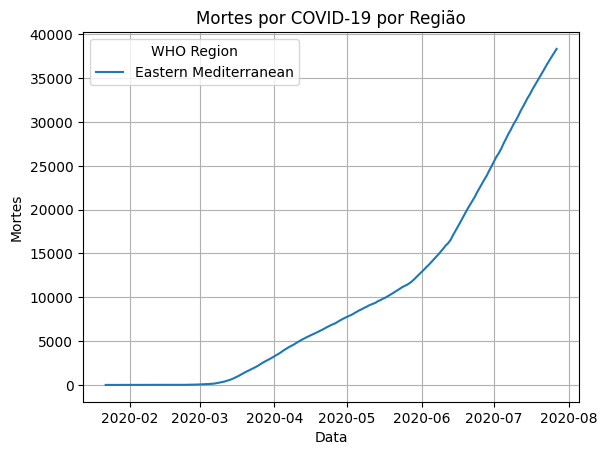

In [30]:
#plotando
sns.lineplot(data=df_filtradoM, x='Date', y='Deaths', hue='WHO Region')

plt.title('Mortes por COVID-19 por Região')
plt.xlabel('Data')
plt.ylabel('Mortes')
plt.grid(True)
plt.legend(title='WHO Region')

plt.show()

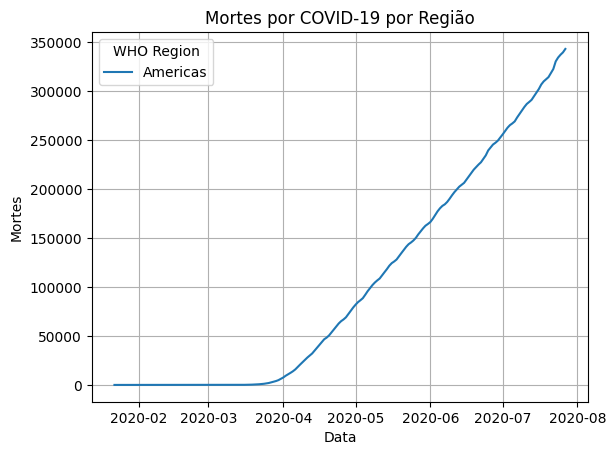

In [31]:
sns.lineplot(data=df_filtradoA, x='Date', y='Deaths', hue='WHO Region')

plt.title('Mortes por COVID-19 por Região')
plt.xlabel('Data')
plt.ylabel('Mortes')
plt.grid(True)
plt.legend(title='WHO Region')

plt.show()

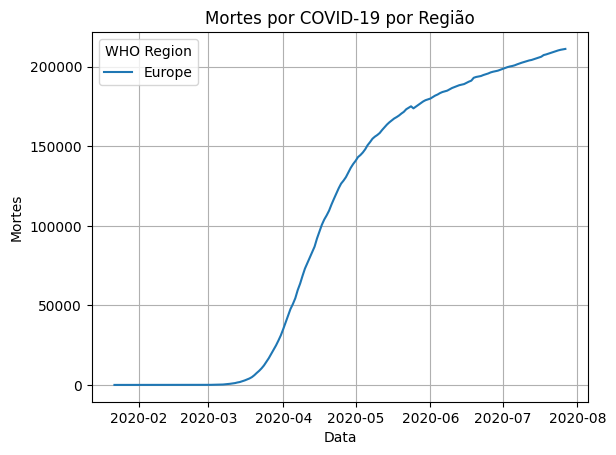

In [32]:
sns.lineplot(data=df_filtradoE, x='Date', y='Deaths', hue='WHO Region')

plt.title('Mortes por COVID-19 por Região')
plt.xlabel('Data')
plt.ylabel('Mortes')
plt.grid(True)
plt.legend(title='WHO Region')

plt.show()

**Conclusões (5.1):**

1) a maior quantidade de mortes foi em easten mediterranenm
2) Começou a crescer a parti de 2020-04
3) Curva 1 se comportou parecido com uma exponencial, a curva 2 se comportou como uma reta e a cursa 3 no começo parecia uma exponencial depois ficou parecido com log ou seja parecendo um S

## 5.2) Gráfico de barras — mortes por continente

In [33]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [34]:
#Arrumando o df
df_mortes=df[['Deaths','WHO Region']]
df_mortes2=df_mortes.groupby('WHO Region')['Deaths'].sum().reset_index()
df_mortes2

,WHO Region,Deaths
0,Africa,439978
1,Americas,19359292
2,Eastern Mediterranean,1924029
3,Europe,19271040
4,South-East Asia,1458134
5,Western Pacific,932430


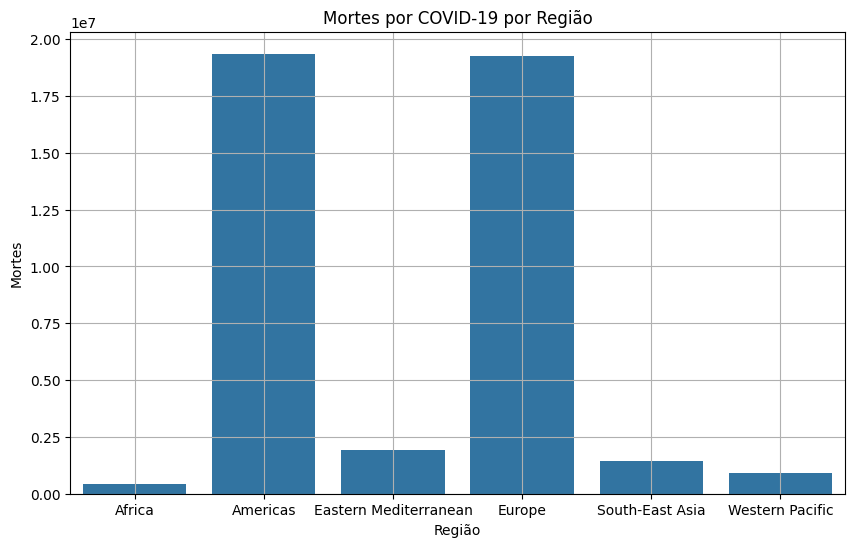

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_mortes2, x='WHO Region', y='Deaths')

plt.title('Mortes por COVID-19 por Região')
plt.xlabel('Região')
plt.ylabel('Mortes')
plt.grid(True)

plt.show()

**Conclusões (5.2):**

1) Americas e Europa
2) Africa


## 5.3) Gráfico de dispersão — população × mortes por milhão

In [36]:
df_2.head(10)

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa
5,Mexico,North America,1.290662e+08,462690,6590.0,50517.0,819.0,308848.0,4140.0,103325.0,3987.0,3585.0,391.0,1056915.0,8189.0,Americas
6,Peru,South America,3.301632e+07,455409,NaN,20424.0,NaN,310337.0,NaN,124648.0,1426.0,13793.0,619.0,2493429.0,75521.0,Americas
7,Chile,South America,1.913251e+07,366671,NaN,9889.0,NaN,340168.0,NaN,16614.0,1358.0,19165.0,517.0,1760615.0,92022.0,Americas
8,Colombia,South America,5.093626e+07,357710,NaN,11939.0,NaN,192355.0,NaN,153416.0,1493.0,7023.0,234.0,1801835.0,35374.0,Americas
9,Spain,Europe,4.675665e+07,354530,NaN,28500.0,NaN,NaN,NaN,NaN,617.0,7582.0,610.0,7064329.0,151087.0,Europe


In [37]:
df_2['Continent'].unique()

array(['North America', 'South America', 'Asia', 'Europe', 'Africa',
       'Australia/Oceania', nan], dtype=object)

In [38]:
#agrupando
df_grupo=df_2.groupby('Continent')['Deaths/1M pop'].mean().sort_values(ascending=False)
df_grupo.head()

,Deaths/1M pop
Continent,
South America,216.769231
Europe,214.955556
North America,110.607143
Asia,43.971429
Africa,18.241455


In [39]:
df_filtrado=df_2.query('`Continent` in ["South America", "Europe", "North America"]')
df_filtrado.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,331198130.0,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,212710692.0,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
3,Russia,Europe,145940924.0,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
5,Mexico,North America,129066160.0,462690,6590.0,50517.0,819.0,308848.0,4140.0,103325.0,3987.0,3585.0,391.0,1056915.0,8189.0,Americas
6,Peru,South America,33016319.0,455409,NaN,20424.0,NaN,310337.0,NaN,124648.0,1426.0,13793.0,619.0,2493429.0,75521.0,Americas


In [40]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 0 to 207
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    97 non-null     object 
 1   Continent         97 non-null     object 
 2   Population        97 non-null     float64
 3   TotalCases        97 non-null     int64  
 4   NewCases          3 non-null      float64
 5   TotalDeaths       86 non-null     float64
 6   NewDeaths         2 non-null      float64
 7   TotalRecovered    93 non-null     float64
 8   NewRecovered      2 non-null      float64
 9   ActiveCases       93 non-null     float64
 10  Serious,Critical  64 non-null     float64
 11  Tot Cases/1M pop  97 non-null     float64
 12  Deaths/1M pop     86 non-null     float64
 13  TotalTests        95 non-null     float64
 14  Tests/1M pop      95 non-null     float64
 15  WHO Region        80 non-null     object 
dtypes: float64(12), int64(1), object(3)
memory usage: 

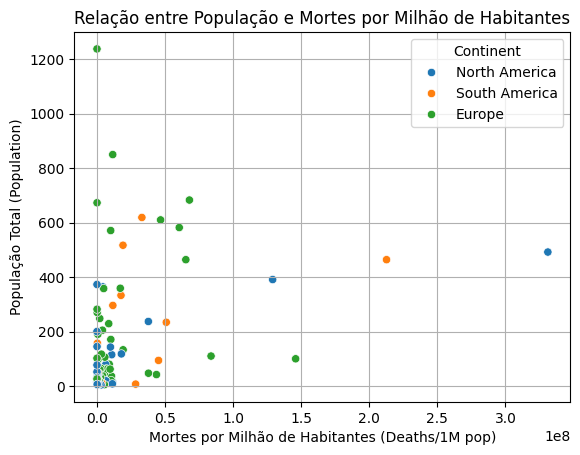

In [41]:
sns.scatterplot(data=df_filtrado, x="Population", y="Deaths/1M pop",hue='Continent')
plt.title('Relação entre População e Mortes por Milhão de Habitantes')
plt.xlabel('Mortes por Milhão de Habitantes (Deaths/1M pop)')
plt.ylabel('População Total (Population)')
plt.grid(True)

**Conclusões (5.3):**

1) há concentração na parte inferior esquerda
2) De forma os paises com baixa população tendem a ter baixa morte por milão de habitante
3) aparentemente os paises com menor populão tendem a ter menor taxa de mortalidade, porém não é um fator decisivo há varios outlier

## 5.4) Mapa de calor de correlação

In [42]:
#matriz
matriz=df_2.corr(numeric_only=True)
matriz

,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop
Population,1.000000,0.546158,0.889610,0.431072,0.910836,0.590239,0.854194,0.459124,0.595379,-0.009337,0.025686,0.497937,-0.075129
TotalCases,0.546158,1.000000,0.999459,0.938622,0.998062,0.985764,0.998258,0.969423,0.967270,0.252627,0.280476,0.891001,0.029141
NewCases,0.889610,0.999459,1.000000,0.991894,0.995554,0.991416,0.999636,0.935500,0.985526,0.321203,0.842468,0.214572,-0.669339
TotalDeaths,0.431072,0.938622,0.991894,1.000000,0.999507,0.935410,0.988362,0.927625,0.906627,0.237206,0.425186,0.850304,0.053870
NewDeaths,0.910836,0.998062,0.995554,0.999507,1.000000,0.998935,0.992651,0.888717,0.997112,0.046499,0.751519,0.039460,-0.803470
TotalRecovered,0.590239,0.985764,0.991416,0.935410,0.998935,1.000000,0.986012,0.914566,0.949628,0.268483,0.296443,0.870113,0.022027
NewRecovered,0.854194,0.998258,0.999636,0.988362,0.992651,0.986012,1.000000,0.937663,0.980595,0.167036,0.825828,-0.081745,-0.869608
ActiveCases,0.459124,0.969423,0.935500,0.927625,0.888717,0.914566,0.937663,1.000000,0.945943,0.212899,0.255001,0.911488,0.028963
"Serious,Critical",0.595379,0.967270,0.985526,0.906627,0.997112,0.949628,0.980595,0.945943,1.000000,0.209668,0.271842,0.859526,0.020649
Tot Cases/1M pop,-0.009337,0.252627,0.321203,0.237206,0.046499,0.268483,0.167036,0.212899,0.209668,1.000000,0.502134,0.194120,0.302728


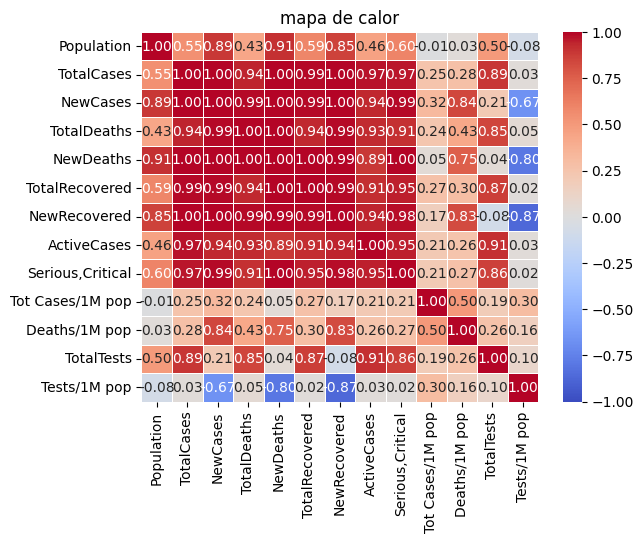

In [43]:
sns.heatmap(
    matriz,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('mapa de calor')
plt.show()

**Observação extra (5.4): População × Testes/1M pop**

1) O grafico indica que é praticamente inexistente a corelação entre as duas variaveis, ou seja uma pais ter uma população grande ou pequena não inteferene na porcetagem de teste por milhão de habitante.

# 6) Introdução ao Machine Learning (Titanic)

In [44]:
#importando
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
np.random.seed(0)


In [45]:
#importando
treino=pd.read_csv('/content/drive/MyDrive/Data/train.csv')
teste=pd.read_csv('/content/drive/MyDrive/Data/test.csv')

## 6.1) Análise exploratória inicial (treino/teste)

In [46]:
treino.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
treino.head(9)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S


In [48]:
#analise exploratoia
treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [49]:
treino.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [50]:
treino.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## 6.2) Tratamento de nulos e seleção de colunas numéricas

In [51]:
treino_n = treino.select_dtypes(include=['int64', 'float64'])
teste_n = teste.select_dtypes(include=['int64', 'float64'])

In [52]:
treino_n = treino_n.dropna()
teste_n = teste_n.fillna(0)

In [53]:
treino_n['Age'].max()

80.0

 Faixas etárias × taxa de sobrevivência

In [54]:
rotulos=['(0-10)', '(10-20)', '(20-30)', '(30-40)', '(40-50)', '(50-60)', '(60-70)', '(70-80)']
bins=[0,10,20,30,40,50,60,70,80]
treino['Faixa_Etaria'] = pd.cut(treino['Age'], bins=bins, labels=rotulos)
treino.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Faixa_Etaria
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,(20-30)
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,(30-40)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,(20-30)
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,(30-40)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,(30-40)


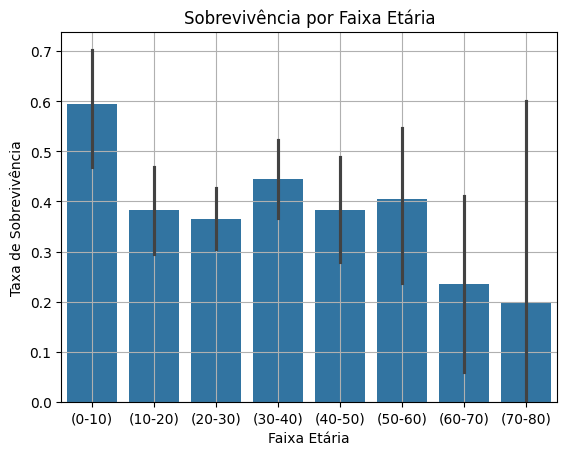

In [55]:
sns.barplot(data=treino, x='Faixa_Etaria', y='Survived')
plt.title('Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência')
plt.grid(True)
plt.show()

Fica visivel uma taxa de sobrevivência maior nas crianças que eram priorizadas e uma taxa baixa de idosos provavelemente pela dificuldade de locomoção



```
# Isto` está formatado como código`
```
#sobrevivente x classe

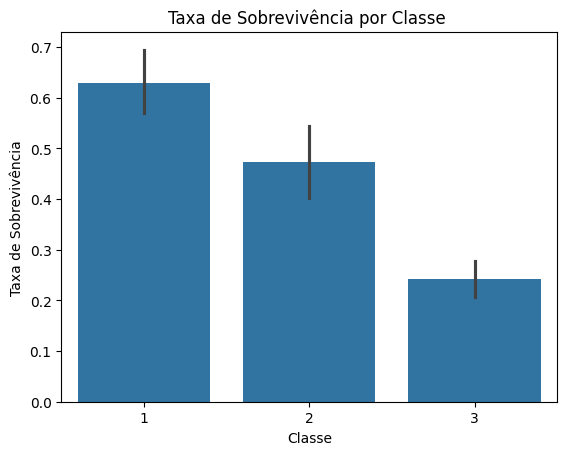

In [56]:

sns.barplot(x='Pclass', y='Survived', data=treino,)
plt.title('Taxa de Sobrevivência por Classe ')
plt.xlabel('Classe')
plt.ylabel('Taxa de Sobrevivência')
plt.show()

 Classe / composição familiar × sobrevivência

Conclusão

1) Pessoas com melhor condição financeira tendem a ter mais regalias e prioridades também além da classe 1 fica mais perto dos botes

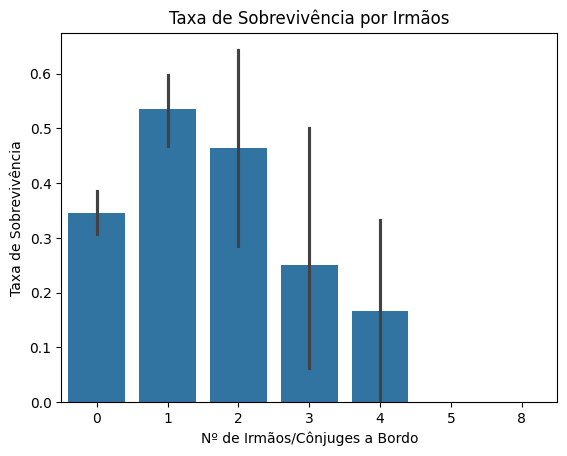

In [57]:
sns.barplot(x='SibSp', y='Survived', data=treino,)
plt.title('Taxa de Sobrevivência por Irmãos')
plt.xlabel('Nº de Irmãos/Cônjuges a Bordo')
plt.ylabel('Taxa de Sobrevivência')
plt.show()

Conclusão

1) Aparentemente familias maiores tiveram mais dificuldade de evacuarem, provalemente pelo logistica que é mais complicada

 Crianças × sobrevivência

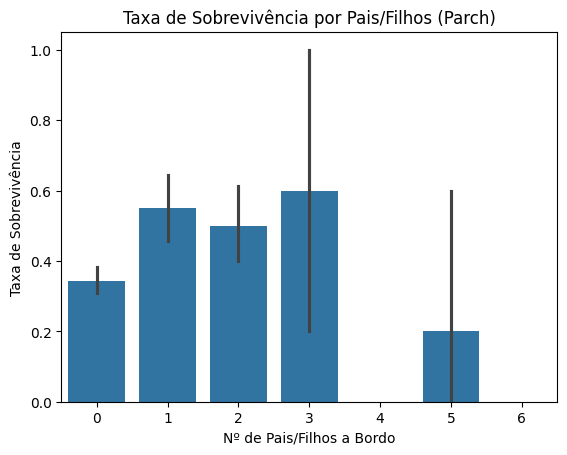

In [58]:

sns.barplot(x='Parch', y='Survived', data=treino,)
plt.title('Taxa de Sobrevivência por Pais/Filhos (Parch)')
plt.xlabel('Nº de Pais/Filhos a Bordo')
plt.ylabel('Taxa de Sobrevivência')
plt.show()

Conclusão

1) Como criança são prioridads familias com mais crianças evacuaram mais rapido, mas familias muito numerosas enfrentaram probe

##6.3)

In [59]:
#importando
from sklearn.model_selection import train_test_split
#retirando colunas
X = treino_n.drop(columns=['PassengerId', 'Survived'])
Y = treino_n['Survived']

In [60]:
#separando para treinamento
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.20, random_state=0)

In [61]:
#importndo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [62]:
#random florest
modelo= RandomForestClassifier(random_state=0)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_val)
acuracia = accuracy_score(y_val, y_pred)
print(  f"Acurácia: {acuracia:.2f}")

Acurácia: 0.67


In [63]:
# Treinando
modelo= RandomForestClassifier(random_state=0)
modelo.fit(X,Y)

RandomForestClassifier(random_state=0)

In [64]:
#id dos passageiros
df_id = teste_n['PassengerId']

In [65]:
#teste
X_teste=teste_n.drop(columns=['PassengerId'])

In [66]:
#predição
y_pred = modelo.predict(X_teste)


In [67]:
submissao = pd.DataFrame({
    'PassengerId': df_id,
    'Survived': y_pred
})
submissao.to_csv('submission.csv', index=False)
submissao.head(80)

,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,0
...,...,...
75,967,1
76,968,1
77,969,0
78,970,0


##7)Data cleaning

# 7.1)Análise inicial

In [68]:
treino=pd.read_csv('/content/drive/MyDrive/Data/train.csv')
teste=pd.read_csv('/content/drive/MyDrive/Data/test.csv')

In [69]:
#colunas treinos
treino.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [70]:
#colunas testes
teste.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [71]:
treino.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [72]:
matriz2=treino.corr(numeric_only=True)
matriz2

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [73]:
treino.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [74]:
teste.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [75]:
treino.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [76]:
teste.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [77]:
train_clear=treino.copy()
test_clear=teste.copy()

#7.2) Tratamento de valores ausentes ou nulos

In [78]:
#retirando colunas
test_clear_1=test_clear.drop(columns=['Cabin','Ticket'])
train_clear_1=train_clear.drop(columns=['Cabin','Ticket'])

In [79]:
#descobrindo mediana
Mediana_train=train_clear_1['Age'].median()
Mediana_test=test_clear_1['Age'].median()

In [80]:
#substituindo valores
train_clear_1['Age']=train_clear_1['Age'].fillna(Mediana_train)
test_clear_1['Age']=test_clear_1['Age'].fillna(Mediana_test)

In [81]:
#fare
teste_fare=test_clear_1['Fare'].median()
train_fare=train_clear_1['Fare'].median()
test_clear_1['Fare']=test_clear_1['Fare'].fillna(teste_fare)
train_clear_1['Fare']=train_clear_1['Fare'].fillna(train_fare)




In [82]:
#embarked
teste_embarked=test_clear_1['Embarked'].mode()[0]
train_embarked=train_clear_1['Embarked'].mode()[0]
test_clear_1['Embarked']=test_clear_1['Embarked'].fillna(teste_embarked)
train_clear_1['Embarked']=train_clear_1['Embarked'].fillna(train_embarked)



In [83]:
test_clear_1.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [84]:
train_clear_1.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


#7.3)Criação de grupos

In [85]:
#Nova coluna age
train_clear_1['Age_Group'] = pd.cut(train_clear_1['Age'], bins=5)
test_clear_1['Age_Group'] = pd.cut(test_clear_1['Age'], bins=5)

In [86]:
#coluna fare
train_clear_1['Fare_Group'] = pd.qcut(train_clear_1['Fare'], q=6)
test_clear_1['Fare_Group'] = pd.qcut(test_clear_1['Fare'], q=6)

#Repostas perguntas
1)"Cabin foi excluída porque a maioria dos valores era nula. Já Ticket foi descartada porque os dados eram muito variados e sem padrão. Um jeito de usar 'Cabin' seria associar os valores com a proximidade dos botes salva-vidas."



2)A moda é recomendada principalmente para três situações: textos, classes e números inteiros com poucas opções. Para textos e categorias, a moda é a única medida de tendência central válida. Ela também é útil para números inteiros quando valores decimais não fazem sentido, como na quantidade de filhos. Por outro lado, a média é melhor utilizada quando os dados seguem uma distribuição normal e não possuem valores extremos.

3)Aumenta artificialmente a categoria mais comum: Se a maioria das pessoas embarcou no porto 'S', colocar 'S' nos dados faltantes faz essa categoria parecer ainda maior do que era de verdade. Isso "vicia" o banco de dados em favor do grupo dominante.

Ignora o perfil do passageiro: A pessoa que está com o dado nulo poderia ter características de outra categoria (por exemplo, ser da 1ª classe e ter embarcado em 'C'). Preencher tudo com a moda ignora qualquer relação com as outras variáveis e força todo mundo para o mesmo lado.

Reduz a variabilidade dos dados: Você elimina a chance de rechear as categorias menores/minoritárias, o que tira a diversidade dos dados e faz o modelo perder nuanced de análise.

4) Vantagens:

Diminui a influência de valores extremos: os outliers ficam represados dentro de um grupo maior, sem distorcer a análise.

Facilita a interpretação dos dados: é mais simples entender e comunicar faixas de valores do que dados contínuos brutos.

Diminui o efeito de ruídos de medição: pequenas variações ou imprecisões no dado acabam caindo no mesmo grupo e não atrapalham o modelo.

Desvantagens:

Perda de informação: perde-se a variação exata do dado. Por exemplo, pessoas de 20 e 30 anos podem cair na mesma faixa, embora estejam em fases de vida bem diferentes.

Efeito de borda: usando a idade como exemplo, se houver um corte nos 30 anos, uma pessoa de 29 e outra de 30 anos são quase idênticas, mas o corte as força a ficarem em faixas diferentes.

5) Em primeiro lugar, temos a remoção de colunas que atrapalham o algoritmo, como Cabin ,que tinha a maior parte dos valores nulos,e Ticket, que não agregava valor ao modelo. Em segundo lugar, a substituição dos valores nulos nas colunas em que isso fazia sentido, usando a média ou a mediana. E, por último, o agrupamento em faixas, permitindo que o algoritmo capture a não-linearidade das chances de sobrevivência

##8)Aperfeiçoamento da modelagem

In [87]:
train_clear_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Fare         891 non-null    float64 
 9   Embarked     891 non-null    object  
 10  Age_Group    891 non-null    category
 11  Fare_Group   891 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 72.0+ KB


In [88]:
#melhorando o pd.cut
train_clear_1['Age_Group'], age_bins = pd.cut(train_clear_1['Age'], bins=5, labels=False, retbins=True)
#bins= quantidade de cortes, labels false = retorna um inteiro, retbins reenviar as faixas de cort
test_clear_1['Age_Group'] = pd.cut(test_clear_1['Age'], bins=age_bins, labels=False, include_lowest=True)
#qcut = mesma quantidade coisas em cada faixa,
train_clear_1['Fare_Group'], fare_bins = pd.qcut(train_clear_1['Fare'], q=6, labels=False, retbins=True)
test_clear_1['Fare_Group'] = pd.cut(test_clear_1['Fare'], bins=fare_bins, labels=False, include_lowest=True)
fare=train_clear_1
#retirando colunas
train_clear_1=train_clear_1.drop(columns=['Age','Fare'])
test_clear_1=test_clear_1.drop(columns=['Age','Fare'])

In [89]:
#onehot
from sklearn.preprocessing import OneHotEncoder
#Tira duvída com monitor entendi poha nenhuma
def apply_one_hot_encoding(df, colunas):
    df_copia = df.copy()
    for coluna in colunas:
        #
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        #
        dados_encoded = ohe.fit_transform(df_copia[[coluna]])
        #
        nomes_novas_colunas = ohe.get_feature_names_out([coluna])
        #
        df_encoded = pd.DataFrame(dados_encoded, columns=nomes_novas_colunas, index=df_copia.index)
        df_copia = df_copia.drop(columns=[coluna])
        df_copia = pd.concat([df_copia, df_encoded], axis=1)
    return df_copia
train_clear_cod=apply_one_hot_encoding(train_clear_1,['Embarked'])
test_clear_cod=apply_one_hot_encoding(test_clear_1,['Embarked'])



In [90]:
from sklearn.preprocessing import LabelEncoder
def label_codificar(df, coluna):
    df_copia = df.copy()
    le = LabelEncoder()
    df_copia[coluna] = le.fit_transform(df_copia[coluna])
    return df_copia

train_clear_cod2 = label_codificar(train_clear_cod, 'Sex')
test_clear_cod2 = label_codificar(test_clear_cod, 'Sex')

In [91]:
train_clear_cod2.head()

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Age_Group,Fare_Group,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,1,0,1,0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,0,2,5,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,0,0,1,1,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,0,2,5,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,0,0,2,1,0.0,0.0,1.0


In [92]:
#treino
X=train_clear_cod2.drop(columns=['Survived','Name','PassengerId'])
y=train_clear_cod2['Survived']

X_train,X_vali,y_train,y_vali=train_test_split(X,y,test_size=0.2,random_state=0)

modelo= RandomForestClassifier(random_state=0)
#treinamento
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_vali)
acuracia = accuracy_score(y_vali, y_pred)
print(  f"Acurácia: {acuracia:.2f}")

Acurácia: 0.82


##8.2) Pipelines

In [93]:
train_pipeline = train_clear.drop(columns=['Cabin', 'Ticket'])
test_pipeline = test_clear.drop(columns=['Cabin', 'Ticket'])

train_pipeline.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [94]:
treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [95]:
teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [96]:
#pipeline
treino1=treino.drop(columns=['Cabin','Ticket'])
teste1=teste.drop(columns=['Cabin','Ticket'])

In [97]:
#importações
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [98]:
0#função
def get_numeric_imputer(estrategia):
    if estrategia == 'zero':
        return SimpleImputer(strategy='constant', fill_value=0)
    return SimpleImputer(strategy=estrategia)

def pipeline(data, encoder, model, numerical_imputer, categorical_imputer):
    df = data.copy()

    features_numericas = df.select_dtypes(include=['int64', 'float64']).columns.drop(['PassengerId', 'Survived'])
    features_categoricas = df.select_dtypes(include=['object']).columns.drop('Name')
    #list= trasnformando em lista
    X = df[list(features_numericas) + list(features_categoricas)]
    y = df['Survived']

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=0)

    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=categorical_imputer)),
        ('encoder', encoder)
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', get_numeric_imputer(numerical_imputer), features_numericas),
        ('cat', cat_pipeline, features_categoricas)
    ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    acuracia = accuracy_score(y_val, y_pred) * 100
    return acuracia



In [99]:
estrategias_imputacao = ['mean', 'median', 'most_frequent', 'zero']

estrategias_encoding = {
    'one-hot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'ordinal': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
}

In [100]:
resultados = []

for imput_strategy in estrategias_imputacao:
    for nome_encoder, encoder_obj in estrategias_encoding.items():
        acc = pipeline(
            data=treino1,
            encoder=encoder_obj,
            model=RandomForestClassifier(random_state=0),
            numerical_imputer=imput_strategy,
            categorical_imputer='most_frequent'
        )
        resultados.append({'imputer_numerico': imput_strategy, 'encoder': nome_encoder, 'acuracia': acc})
        print(f"Imputer: {imput_strategy:15s} | Encoder: {nome_encoder:8s} | Acurácia: {acc:.2f}%")

df_resultados = pd.DataFrame(resultados).sort_values('acuracia', ascending=False)
df_resultados

Imputer: mean            | Encoder: one-hot  | Acurácia: 86.03%
Imputer: mean            | Encoder: ordinal  | Acurácia: 83.80%
Imputer: median          | Encoder: one-hot  | Acurácia: 84.36%
Imputer: median          | Encoder: ordinal  | Acurácia: 83.80%
Imputer: most_frequent   | Encoder: one-hot  | Acurácia: 86.03%
Imputer: most_frequent   | Encoder: ordinal  | Acurácia: 84.92%
Imputer: zero            | Encoder: one-hot  | Acurácia: 83.80%
Imputer: zero            | Encoder: ordinal  | Acurácia: 83.24%


,imputer_numerico,encoder,acuracia
0,mean,one-hot,86.033520
4,most_frequent,one-hot,86.033520
5,most_frequent,ordinal,84.916201
2,median,one-hot,84.357542
3,median,ordinal,83.798883
1,mean,ordinal,83.798883
6,zero,one-hot,83.798883
7,zero,ordinal,83.240223


##8.3)Cross Validation e Gradient Boosting

In [101]:
#Cross Validation
from sklearn.model_selection import cross_val_score
#X=independetes, y=dependente, a cross_val ja faz o treinamento e a validação, CV= número de divisões
pontuação=cross_val_score(RandomForestClassifier(random_state=0), X, y, cv=5, scoring="accuracy")
print(f'pontuação média:{pontuação.mean():.2f}')

pontuação média:0.80


In [102]:
#gradiente boosting
from sklearn.ensemble import GradientBoostingClassifier
#o ultimo parametro fala do número de tentativas máximas sem mudança significativa
modelo_gradiente= GradientBoostingClassifier(random_state=0, n_iter_no_change=100)

In [103]:
from sklearn.model_selection import cross_val_score

scores_gradiente = cross_val_score(modelo_gradiente, X, y, cv=5, scoring="accuracy")

print(f"Scores em cada divisão: {scores_gradiente}")
print(f"Acurácia média  {scores_gradiente.mean()*100:.2f}%")

Scores em cada divisão: [0.7877095  0.7752809  0.8258427  0.78651685 0.83707865]
Acurácia média  80.25%


O gradiente boosting teve um desempenho ligeiramente maior de 0.25%

##9)Feature Engineering

9.1)Feature Selection

In [104]:
#inteiros
from sklearn.feature_selection import mutual_info_classif
#target
X=train_clear_cod2.drop(columns=['Survived', 'Name', 'PassengerId'])
y=train_clear_cod2['Survived']
X[['Embarked_C', 'Embarked_Q', 'Embarked_S']] = X[['Embarked_C', 'Embarked_Q', 'Embarked_S']].astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Pclass      891 non-null    int64
 1   Sex         891 non-null    int64
 2   SibSp       891 non-null    int64
 3   Parch       891 non-null    int64
 4   Age_Group   891 non-null    int64
 5   Fare_Group  891 non-null    int64
 6   Embarked_C  891 non-null    int64
 7   Embarked_Q  891 non-null    int64
 8   Embarked_S  891 non-null    int64
dtypes: int64(9)
memory usage: 62.8 KB


In [105]:
#parametros discretos
features_dis= X.dtypes == int

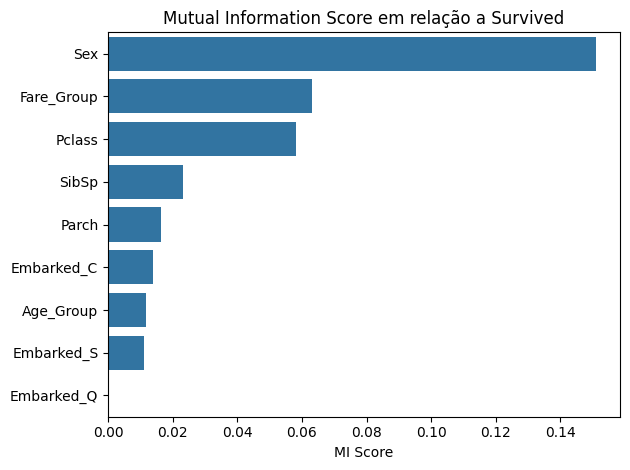

Sex           0.150870
Fare_Group    0.063044
Pclass        0.058107
SibSp         0.023197
Parch         0.016366
Embarked_C    0.013803
Age_Group     0.011665
Embarked_S    0.011028
Embarked_Q    0.000007
Name: MI Scores, dtype: float64


In [106]:
#Função


def mi_scores_grafico(X, y, features_dis):
    #descobrindo as correlações
    mi_scores=mutual_info_classif(X,y,discrete_features=features_dis)
    #nomeando as colunas pd.series+cria um array unidemensional,mi_scores=valores, subistitui o index pelos nomes das colunas
    mi_scores=pd.Series(mi_scores, name='MI Scores', index=X.columns)
    #ordenando
    mi_scores=mi_scores.sort_values(ascending=False)
    #graficos
    sns.barplot(x=mi_scores,y=mi_scores.index)
    plt.title("Mutual Information Score em relação a Survived")
    plt.xlabel("MI Score")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    return mi_scores
#chamado a função
mi_score = mi_scores_grafico(X, y, features_dis)
print(mi_score)

9.1.2

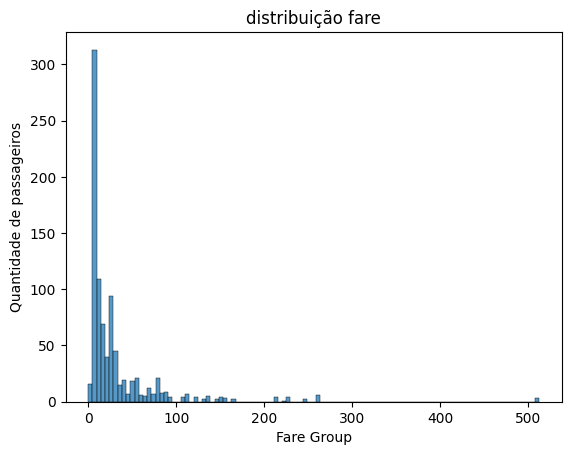

In [107]:
 #fare
 sns.histplot(data=fare, x='Fare')
 plt.title('distribuição fare')
 plt.xlabel('Fare Group')
 plt.ylabel('Quantidade de passageiros')
 plt.show()

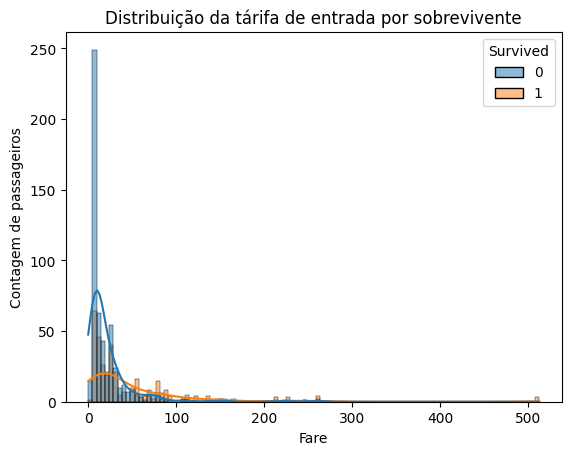

In [108]:
sns.histplot(data=fare, x='Fare', hue='Survived', kde=True, )
plt.title("Distribuição da tárifa de entrada por sobrevivente")
plt.xlabel("Fare")
plt.ylabel("Contagem de passageiros")
plt.show()

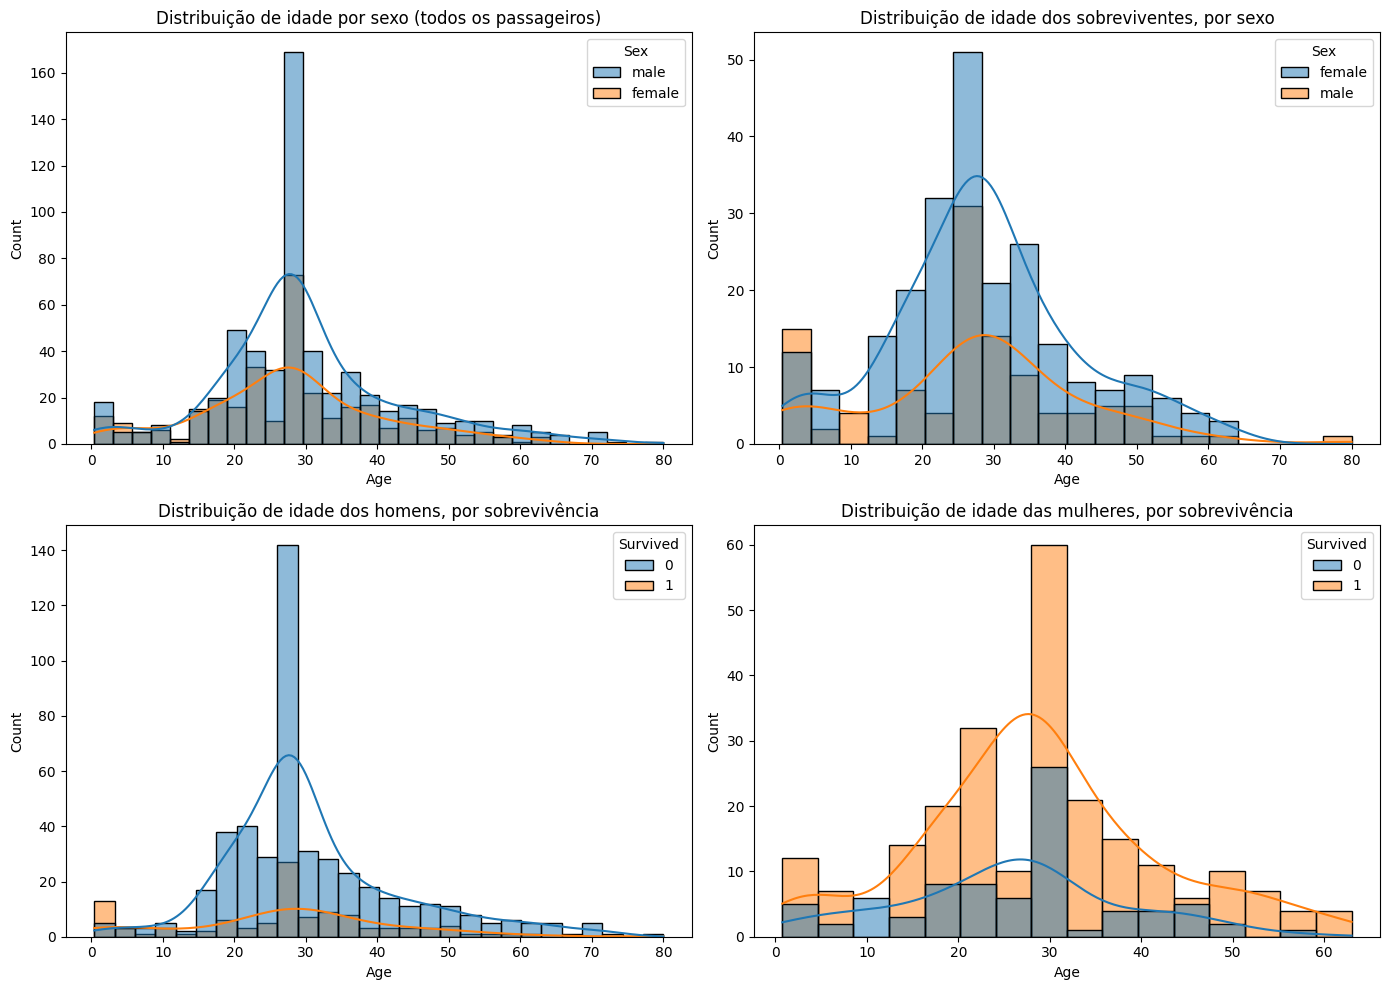

In [119]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Idade por sexo
sns.histplot(data=fare, x='Age', hue='Sex', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Idade por sexo')

#idades do sobreviventes por sexo
sobreviventes =fare.query("Survived == 1")
sns.histplot(data=sobreviventes, x='Age', hue='Sex', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Idade dos sobreviventes, por sexo')

#idade dos homens que sobreviveram
homens = fare.query("Sex == 'male'")
sns.histplot(data=homens, x='Age', hue='Survived', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Idade dos homens sobreviventes')

#idade das mulheres que sobrevivre
mulheres = fare.query("Sex == 'female'")
sns.histplot(data=mulheres, x='Age', hue='Survived', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Idade das mulheres sobrevivementes')

plt.tight_layout()
plt.show()

##9.2)feature construction

In [110]:
# data set nomes
train_titles = train_clear.copy()
test_titles = test_clear.copy()

# arrumando os nomes
train_titles['Title'] = train_titles['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
test_titles['Title'] = test_titles['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

train_titles = train_titles.drop(columns=['Name'])
test_titles = test_titles.drop(columns=['Name'])

train_titles['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [111]:
train_titles['FamilySize'] = train_titles['SibSp'] + train_titles['Parch']
test_titles['FamilySize'] = test_titles['SibSp'] + test_titles['Parch']

train_titles['IsAlone'] = train_titles['FamilySize'] == 0
test_titles['IsAlone'] = test_titles['FamilySize'] == 0

train_titles[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,1,False
1,1,0,1,False
2,0,0,0,True
3,1,0,1,False
4,0,0,0,True


##9.3)Feature Extraction

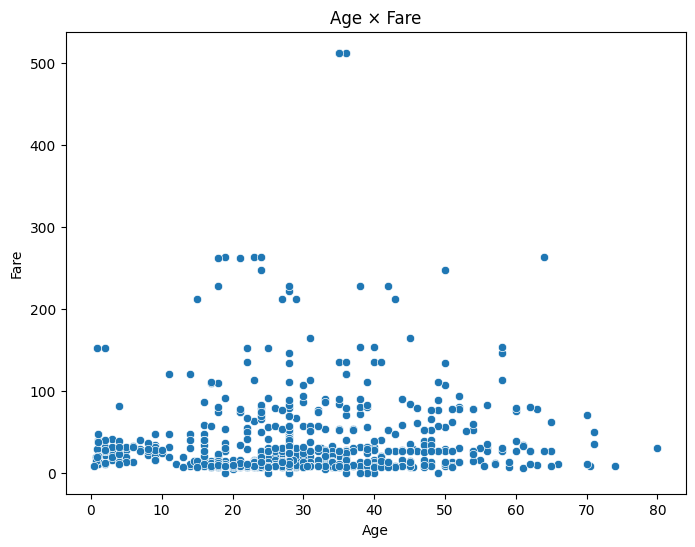

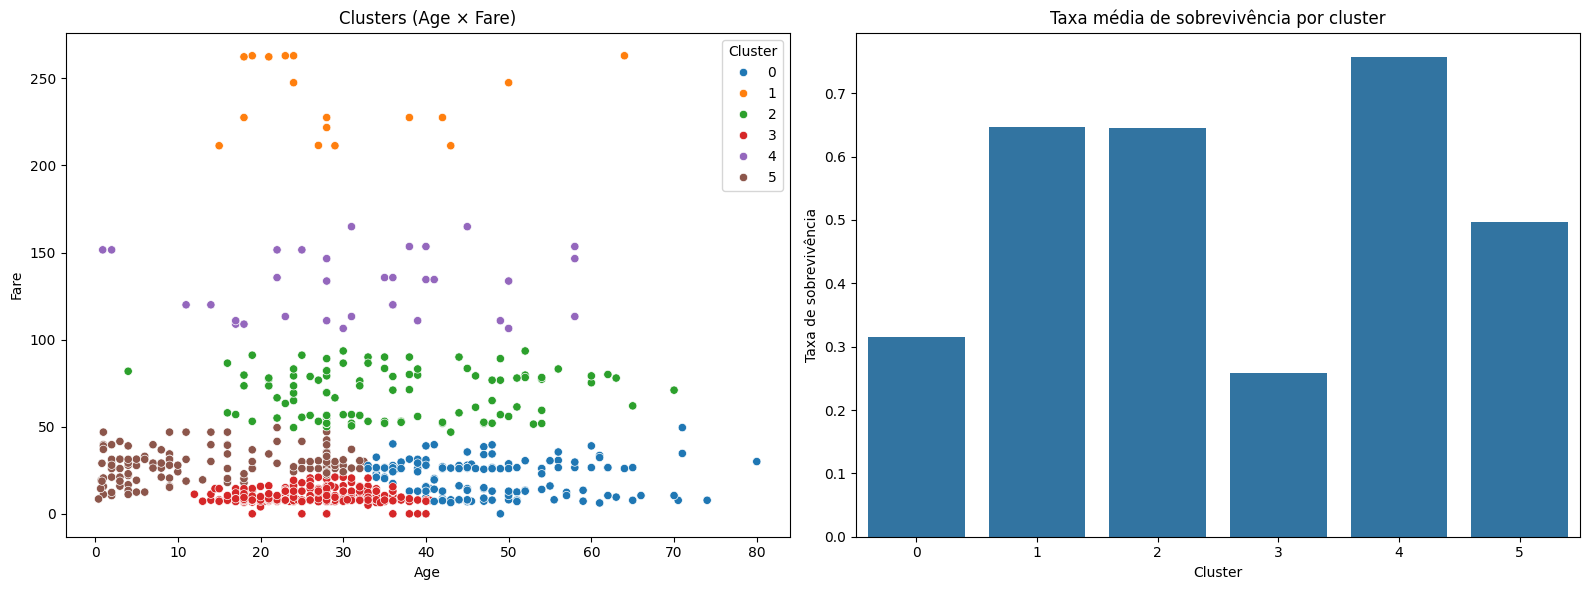

In [112]:
from sklearn.cluster import KMeans

# grafico de pontos
plt.figure(figsize=(8, 6))
sns.scatterplot(data=fare, x='Age', y='Fare')
plt.title('Age × Fare')
plt.show()

#removendo outliers
fare_sem_outliers = fare[fare['Fare'] < 500].copy()

# kmeans com 6 cluster
kmeans = KMeans(n_clusters=6, random_state=0, n_init=10)
fare_sem_outliers['Cluster'] = kmeans.fit_predict(fare_sem_outliers[['Age', 'Fare']])


fare['Cluster'] = fare_sem_outliers['Cluster']

# (f) gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=fare_sem_outliers, x='Age', y='Fare', hue='Cluster', palette='tab10', ax=axes[0])
axes[0].set_title('Clusters Age × Fare')
media_por_cluster = fare_sem_outliers.groupby('Cluster')['Survived'].mean()
sns.barplot(x=media_por_cluster.index, y=media_por_cluster.values, ax=axes[1])
axes[1].set_title('Taxa media de sobrevivência por cluster')
axes[1].set_ylabel('Taxa de sobrevivência')

plt.tight_layout()
plt.show()

##9.3.2

In [120]:
# nulos
fare.loc[fare['Cluster'].isnull()]

#cluster
fare.loc[fare['Cluster'].isnull(), 'Cluster'] = fare_sem_outliers.groupby('Cluster')['Fare'].mean().idxmax()


fare['Cluster'].isnull().sum()

np.int64(0)

In [114]:
X_cluster = fare[['Cluster']].astype(int)
y_cluster = fare['Survived']

mutual_info_classif(X_cluster, y_cluster, discrete_features=[True], random_state=0)

array([0.05555339])

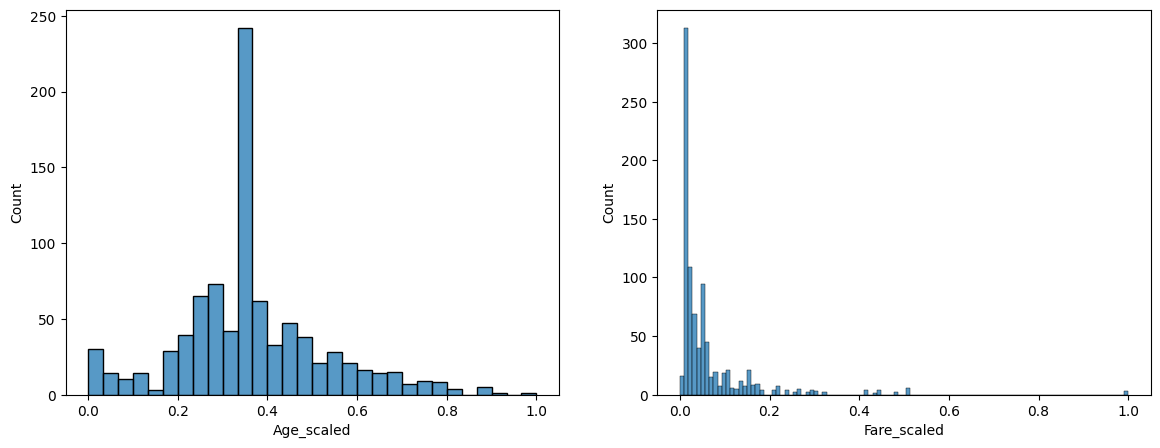

Variância explicada: [0.74364747]
Pesos (loadings): [[0.99617546 0.0873753 ]]


In [115]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# scaling 0-1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(fare[['Age', 'Fare']])
fare_scaled = pd.DataFrame(scaled, columns=['Age_scaled', 'Fare_scaled'], index=fare.index)

#histogramas d
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(fare_scaled['Age_scaled'], ax=axes[0])
sns.histplot(fare_scaled['Fare_scaled'], ax=axes[1])
plt.show()

#PCA
pca = PCA(n_components=1, random_state=0)
componente = pca.fit_transform(fare_scaled)
fare['PCA_Age_Fare'] = componente

#Componentes
print("Variância explicada:", pca.explained_variance_ratio_)
print("Pesos (loadings):", pca.components_)

##9.4) Target Encoding

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 3.2 MB/s eta 0:00:00


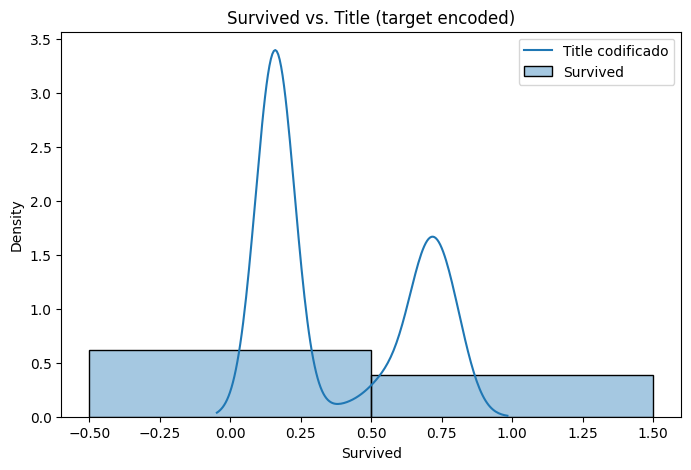

In [116]:
!pip install category_encoders --quiet
from category_encoders import MEstimateEncoder

encoder = MEstimateEncoder(cols=['Title'], m=5.0)
df_title_encoded = encoder.fit_transform(train_titles['Title'], train_titles['Survived'])

#distribuição
plt.figure(figsize=(8, 5))
sns.histplot(train_titles['Survived'], stat='density', discrete=True, alpha=0.4, label='Survived')
sns.kdeplot(df_title_encoded['Title'], label='Title codificado')
plt.legend()
plt.title('Survived vs. Title (target encoded)')
plt.show()